# Visualization of Posterior Distribution


In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [39]:
# Define a two-layer neural network
class TwoLayerNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [40]:
# Initialize model, loss, and optimizer
model = TwoLayerNN(input_size=10, hidden_size=64, output_size=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Create dummy data
X = torch.randn(100, 10)
y = torch.randn(100, 1)
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [41]:
# Training loop with mini-batch
num_epochs = 10
for epoch in range(num_epochs):
    for batch_X, batch_y in dataloader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
# %%

Epoch [1/10], Loss: 1.9782
Epoch [2/10], Loss: 1.5403
Epoch [3/10], Loss: 1.3148
Epoch [4/10], Loss: 0.6456
Epoch [5/10], Loss: 0.9030
Epoch [6/10], Loss: 1.1930
Epoch [7/10], Loss: 0.5785
Epoch [8/10], Loss: 1.2507
Epoch [9/10], Loss: 1.0223
Epoch [10/10], Loss: 1.0394


In [44]:
# Gather the model parameters for covariance calculation
def get_model_parameters(model):
    params = []
    for param in model.parameters():
        params.append(param.view(-1))
    return torch.cat(params)


# Example usage
model = TwoLayerNN(input_size=10, hidden_size=64, output_size=1)
params = get_model_parameters(model)
print("Model parameters shape:", params.shape)

Model parameters shape: torch.Size([769])


In [45]:
# Calculate the covariance matrix of the model parameters
def calculate_covariance_matrix(params):
    mean = torch.mean(params)
    centered_params = params - mean
    covariance_matrix = torch.mm(centered_params.unsqueeze(1), centered_params.unsqueeze(0)) / (params.size(0) - 1)
    return covariance_matrix


# Example usage
cov_matrix = calculate_covariance_matrix(params)
print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: torch.Size([769, 769])


In [47]:
temp = params.detach().numpy()
print(type(temp), temp.shape)

<class 'numpy.ndarray'> (769,)


In [48]:
print("Covariance matrix:\n", cov_matrix)

Covariance matrix:
 tensor([[ 7.0422e-05,  5.4457e-05,  1.9543e-05,  ...,  4.2469e-05,
         -1.4645e-05,  6.1050e-06],
        [ 5.4457e-05,  4.2111e-05,  1.5113e-05,  ...,  3.2841e-05,
         -1.1325e-05,  4.7209e-06],
        [ 1.9543e-05,  1.5113e-05,  5.4235e-06,  ...,  1.1786e-05,
         -4.0642e-06,  1.6942e-06],
        ...,
        [ 4.2469e-05,  3.2841e-05,  1.1786e-05,  ...,  2.5611e-05,
         -8.8319e-06,  3.6817e-06],
        [-1.4645e-05, -1.1325e-05, -4.0642e-06,  ..., -8.8319e-06,
          3.0456e-06, -1.2696e-06],
        [ 6.1050e-06,  4.7209e-06,  1.6942e-06,  ...,  3.6817e-06,
         -1.2696e-06,  5.2925e-07]], grad_fn=<DivBackward0>)


In [21]:
mat_to_plot = cov_matrix.detach().cpu().numpy()
type(mat_to_plot)

numpy.ndarray

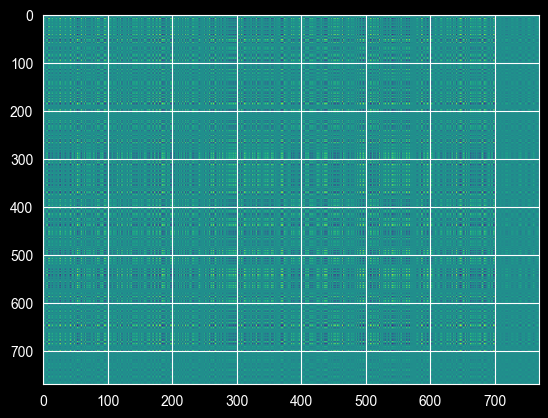

In [49]:
# Visualize covariance matrix using a heatmap
import matplotlib.pyplot as plt

plt.imshow(mat_to_plot, cmap='viridis', aspect='auto')
plt.show()
